In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
E  = 210000.0
nu = 0.0
Y0 = E / 2
h  = E / 100 #linear isotropic hardening modulus

Y_inf  = E / 2 + E / 10   
delta  = 10.0                      

# Kinematic hardening
H_kin  = E / 100 # kinematic hardening modulus

In [3]:
def mat_inv(A):  return np.linalg.inv(A)
def mat_det(A):  return np.linalg.det(A)

In [4]:
def push_forward(sig3, A, J):
    S = np.array([[sig3[0], sig3[2]],
                  [sig3[2], sig3[1]]])
    S_new = (A @ S @ A.T) / J
    return np.array([S_new[0,0], S_new[1,1], S_new[0,1]])

In [5]:
def radial_return_linear(sig_trial_3, eps_p, Y_cur, G, h):
    sv = np.array([sig_trial_3[0], sig_trial_3[1], 0.0,
                   0.0, 0.0, sig_trial_3[2]])
    p  = (sv[0]+sv[1]+sv[2])/3.0
    s  = sv.copy(); s[0]-=p; s[1]-=p; s[2]-=p
    seq = np.sqrt(1.5*(s[0]**2+s[1]**2+s[2]**2
                       +2*(s[3]**2+s[4]**2+s[5]**2)))
    if seq - Y_cur <= 0.0:
        return sig_trial_3.copy(), eps_p, Y_cur
    dgamma  = (seq - Y_cur)/(3*G + h)
    n_dir   = s/seq
    s_new   = s - 2*G*dgamma*n_dir
    sv_new  = s_new.copy()
    sv_new[0]+=p; sv_new[1]+=p; sv_new[2]+=p
    eps_p  += np.sqrt(2/3)*dgamma
    Y_cur   = Y0 + h*eps_p
    return np.array([sv_new[0], sv_new[1], sv_new[5]]), eps_p, Y_cur

In [6]:
def radial_return_nonlinear_iso(sig_trial_3, eps_p, Y_cur, G,
                                Y0, Y_inf, delta):
    sv = np.array([sig_trial_3[0], sig_trial_3[1], 0.0,
                   0.0, 0.0, sig_trial_3[2]])
    p  = (sv[0]+sv[1]+sv[2])/3.0
    s  = sv.copy(); s[0]-=p; s[1]-=p; s[2]-=p
    seq = np.sqrt(1.5*(s[0]**2+s[1]**2+s[2]**2
                       +2*(s[3]**2+s[4]**2+s[5]**2)))

    def Y_voce(ep):
        return Y0 + (Y_inf - Y0)*(1.0 - np.exp(-delta*ep))

    def dY_voce(ep):
        return (Y_inf - Y0)*delta*np.exp(-delta*ep)

    if seq - Y_voce(eps_p) <= 0.0:
        return sig_trial_3.copy(), eps_p, Y_cur

    # Newton iteration for dgamma
    dgamma = 0.0
    for _ in range(50):
        ep_new = eps_p + np.sqrt(2/3)*dgamma
        f  = seq - 3*G*dgamma - Y_voce(ep_new)
        df = -3*G - dY_voce(ep_new)*np.sqrt(2/3)
        ddg = -f/df
        dgamma += ddg
        if abs(ddg) < 1e-12*abs(dgamma)+1e-15:
            break

    ep_new  = eps_p + np.sqrt(2/3)*dgamma
    Y_new   = Y_voce(ep_new)
    n_dir   = s/seq
    s_new   = s - 2*G*dgamma*n_dir
    sv_new  = s_new.copy()
    sv_new[0]+=p; sv_new[1]+=p; sv_new[2]+=p
    return np.array([sv_new[0], sv_new[1], sv_new[5]]), ep_new, Y_new

In [8]:
def radial_return_kinematic(sig_trial_3, eps_p, alpha, G, Y0, H_kin):
    
    sv = np.array([sig_trial_3[0], sig_trial_3[1], 0.0,
                   0.0, 0.0, sig_trial_3[2]])
    p  = (sv[0]+sv[1]+sv[2])/3.0
    s  = sv.copy(); s[0]-=p; s[1]-=p; s[2]-=p

    # Relative deviatoric stress (shifted by back-stress)
    av = np.array([alpha[0], alpha[1], 0.0, 0.0, 0.0, alpha[2]])
    eta = s - av   # relative stress

    seq_eta = np.sqrt(1.5*(eta[0]**2+eta[1]**2+eta[2]**2
                           +2*(eta[3]**2+eta[4]**2+eta[5]**2)))

    # Yield threshold for kinematic: sqrt(2/3)*Y0
    threshold = np.sqrt(2/3)*Y0

    if seq_eta - threshold <= 0.0:
        return sig_trial_3.copy(), eps_p, alpha.copy()

    dgamma  = (seq_eta - threshold) / (2*G + (2/3)*H_kin)
    n_dir   = eta / seq_eta

    s_new   = s - 2*G*dgamma*n_dir
    sv_new  = s_new.copy()
    sv_new[0]+=p; sv_new[1]+=p; sv_new[2]+=p

    # Update back-stress
    alpha_new    = alpha.copy()
    alpha_new[0] += (2/3)*H_kin*dgamma*n_dir[0]*1.5   # factor from Voigt
    alpha_new[1] += (2/3)*H_kin*dgamma*n_dir[1]*1.5
    alpha_new[2] += (2/3)*H_kin*dgamma*n_dir[5]*1.5

    eps_p_new = eps_p + np.sqrt(2/3)*dgamma

    return np.array([sv_new[0], sv_new[1], sv_new[5]]), eps_p_new, alpha_new

In [9]:
def get_F(test, t):
    if test == 'ext_comp':
        return np.array([[1+t, 0],[0, 1/(1+t)]])
    elif test == 'dilatation':
        return np.array([[1+t, 0],[0, 1+t]])
    elif test == 'ext_rot':
        c = np.cos(2*np.pi*t); s = np.sin(2*np.pi*t)
        return np.array([[(1+t)*c, -s],[(1+t)*s, c]])
    else:
        raise ValueError(f"Unknown test: {test}")

In [10]:
def run_algorithm(test, num_steps, algo, hardening,
                  E, nu, Y0, h,
                  Y_inf=None, delta=None, H_kin=None):

    G   = E / (2*(1+nu))
    K   = E / (3*(1-2*nu)) if nu > 0 else E/3
    lam = K - 2*G/3

    sigma  = np.zeros(3)   
    eps_p  = 0.0
    Y_cur  = Y0
    alpha  = np.zeros(3) 

    times, sxx_list, syy_list = [], [], []
    t_prev = 0.0

    for n in range(num_steps):
        t_new = (n+1)/num_steps
        t_mid = 0.5*(t_prev+t_new)

        F_n   = get_F(test, t_prev)
        F_np1 = get_F(test, t_new)
        F_mid = get_F(test, t_mid)

        # ── strain increment depending on algorithm ──────────────────────────
        if algo == 'small':
            grad_du = (F_np1 - F_n) @ mat_inv(F_n)
            deps    = 0.5*(grad_du + grad_du.T)
            push_sig   = sigma.copy()  
            push_dsig  = None           

        elif algo == 'first':
            nA      = F_np1 @ mat_inv(F_n)
            nJ      = mat_det(nA)
            AtA     = nA.T @ nA
            deps    = 0.5*(AtA - np.eye(2))
            push_sig = push_forward(sigma, nA, nJ)

        elif algo == 'second':
            nA      = F_np1 @ mat_inv(F_n)
            nJ      = mat_det(nA)
            nhalfA  = F_np1 @ mat_inv(F_mid)
            nhalfJ  = mat_det(nhalfA)
            grad_du = (F_np1 - F_n) @ mat_inv(F_mid)
            deps    = 0.5*(grad_du + grad_du.T)
            push_sig = push_forward(sigma, nA, nJ)

        # ── elastic trial stress increment ───────────────────────────────────
        ds_xx = (lam+2*G)*deps[0,0] + lam*deps[1,1]
        ds_yy = (lam+2*G)*deps[1,1] + lam*deps[0,0]
        ds_xy = G*2*deps[0,1]
        delta_sig = np.array([ds_xx, ds_yy, ds_xy])

        # ── assemble trial stress ────────────────────────────────────────────
        if algo == 'small':
            sig_trial = push_sig + delta_sig

        elif algo == 'first':
            dsig_pushed = push_forward(delta_sig, nA, nJ)
            sig_trial   = push_sig + dsig_pushed

        elif algo == 'second':
            dsig_pushed = push_forward(delta_sig, nhalfA, nhalfJ)
            sig_trial   = push_sig + dsig_pushed

        # ── plastic correction ───────────────────────────────────────────────
        if hardening == 'linear_iso':
            sigma, eps_p, Y_cur = radial_return_linear(
                sig_trial, eps_p, Y_cur, G, h)

        elif hardening == 'nonlinear_iso':
            sigma, eps_p, Y_cur = radial_return_nonlinear_iso(
                sig_trial, eps_p, Y_cur, G, Y0, Y_inf, delta)

        elif hardening == 'kinematic':
            sigma, eps_p, alpha = radial_return_kinematic(
                sig_trial, eps_p, alpha, G, Y0, H_kin)

        elif hardening == 'elastic':
            sigma = sig_trial

        times.append(t_new)
        sxx_list.append(sigma[0]/E)
        syy_list.append(sigma[1]/E)
        t_prev = t_new

    return np.array(times), np.array(sxx_list), np.array(syy_list)

In [11]:
def analytical_solution(test, t_arr):
    if test == 'ext_comp':
        return np.log(1+t_arr), -np.log(1+t_arr)
    elif test == 'dilatation':
        s = np.log(1+t_arr); return s, s
    elif test == 'ext_rot':
        sxx = t_arr*np.cos(2*np.pi*t_arr)**2
        syy = t_arr*np.sin(2*np.pi*t_arr)**2
        return sxx, syy

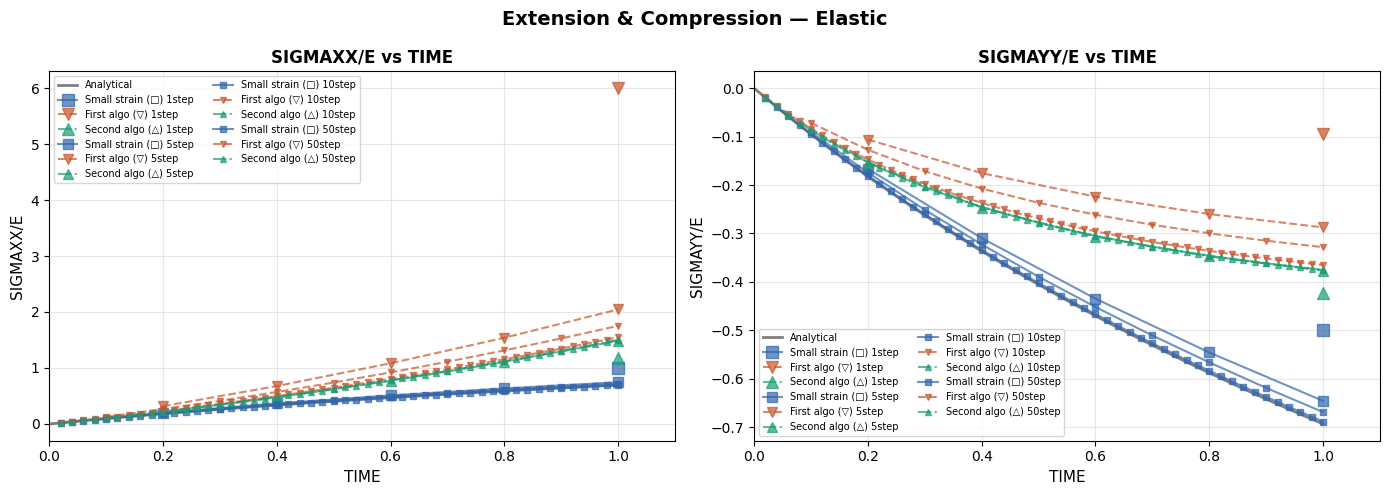

Saved: ext_comp_elastic.png


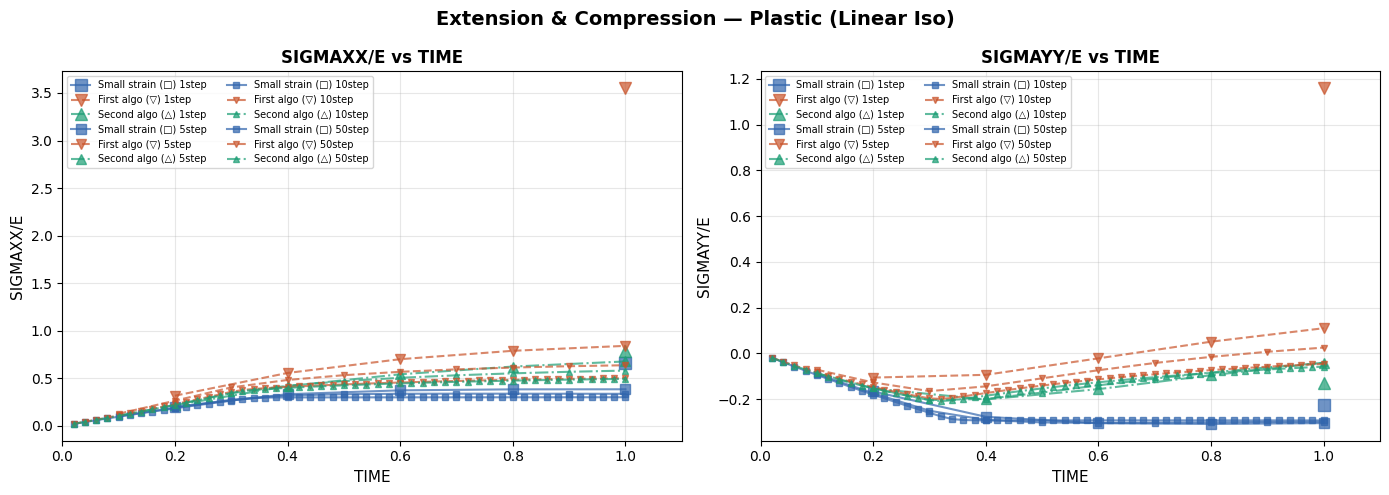

Saved: ext_comp_plastic_(linear_iso).png


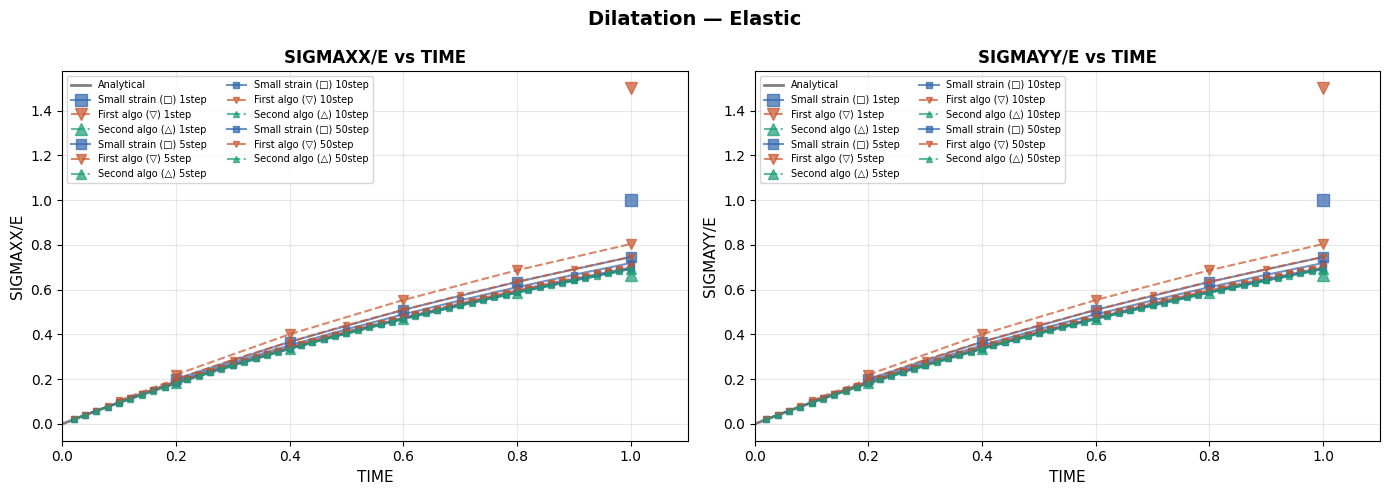

Saved: dilatation_elastic.png


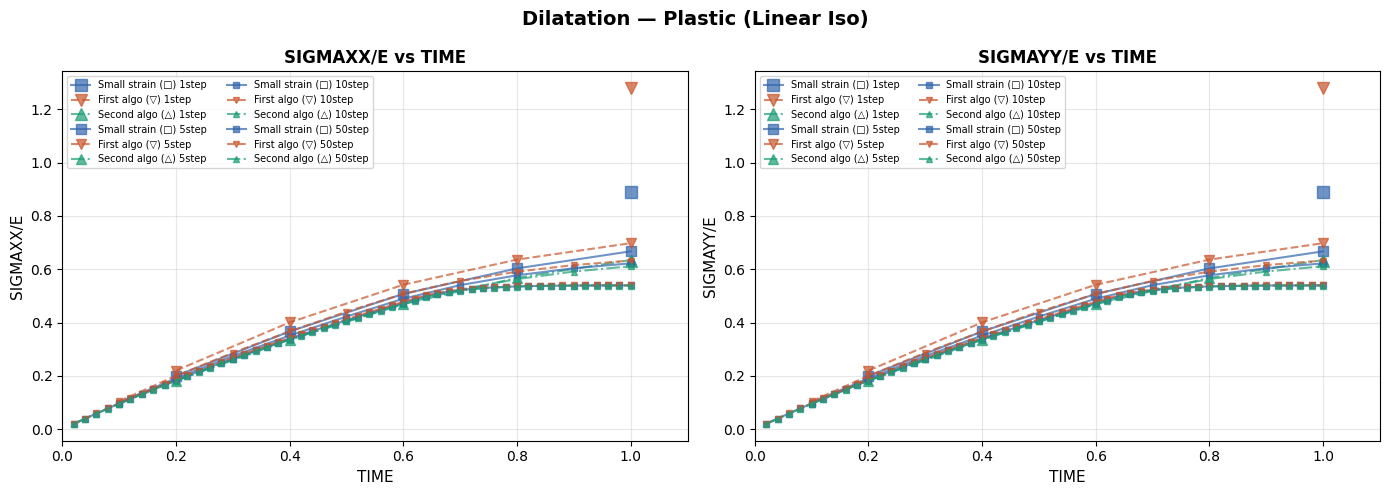

Saved: dilatation_plastic_(linear_iso).png


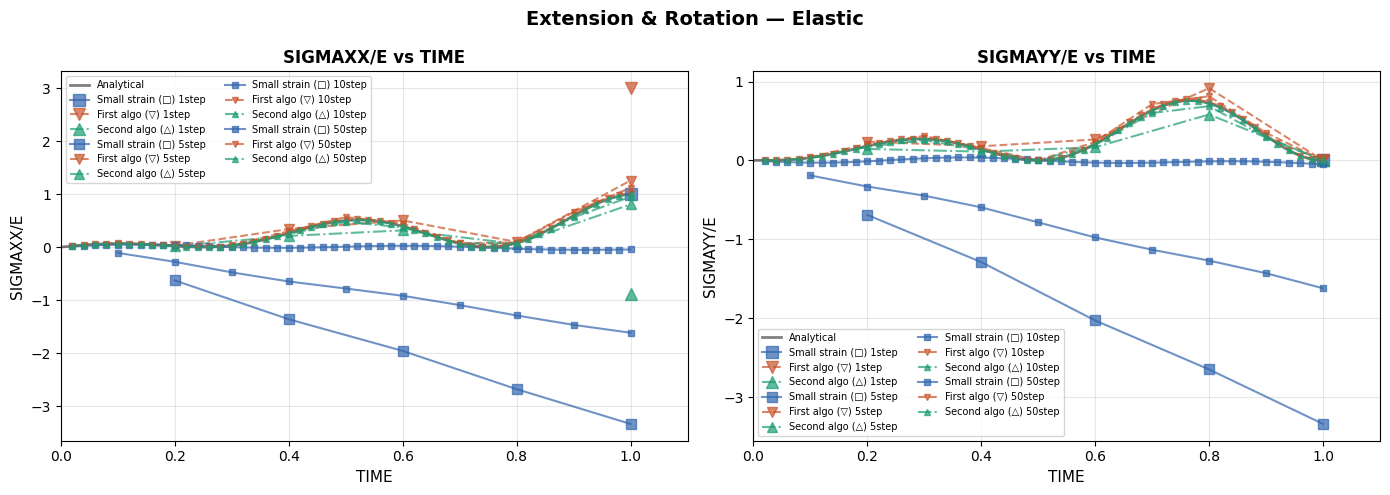

Saved: ext_rot_elastic.png


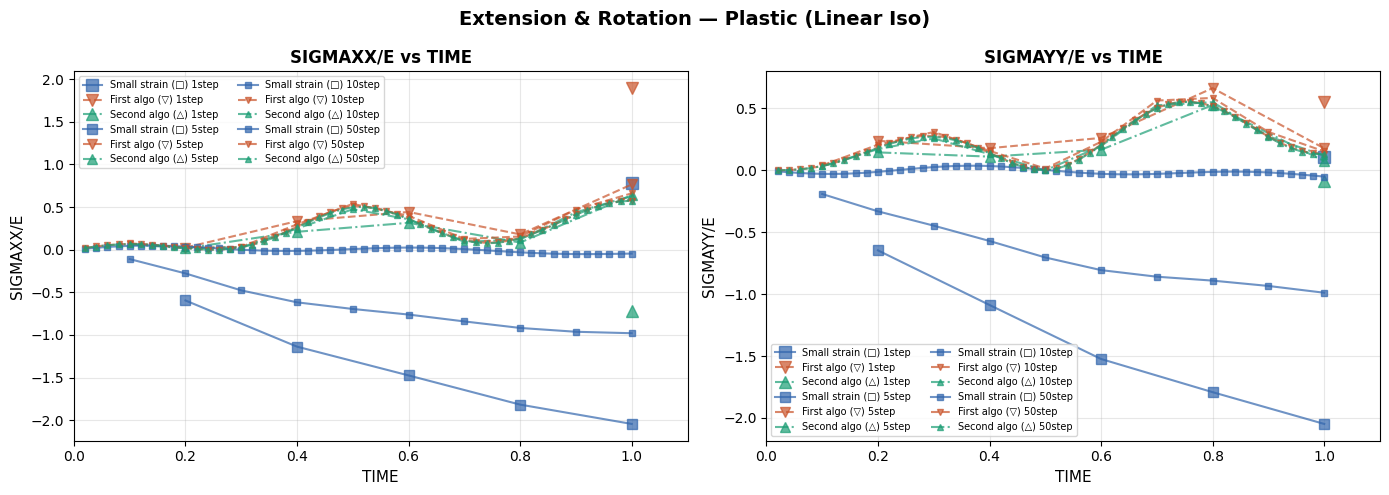

Saved: ext_rot_plastic_(linear_iso).png


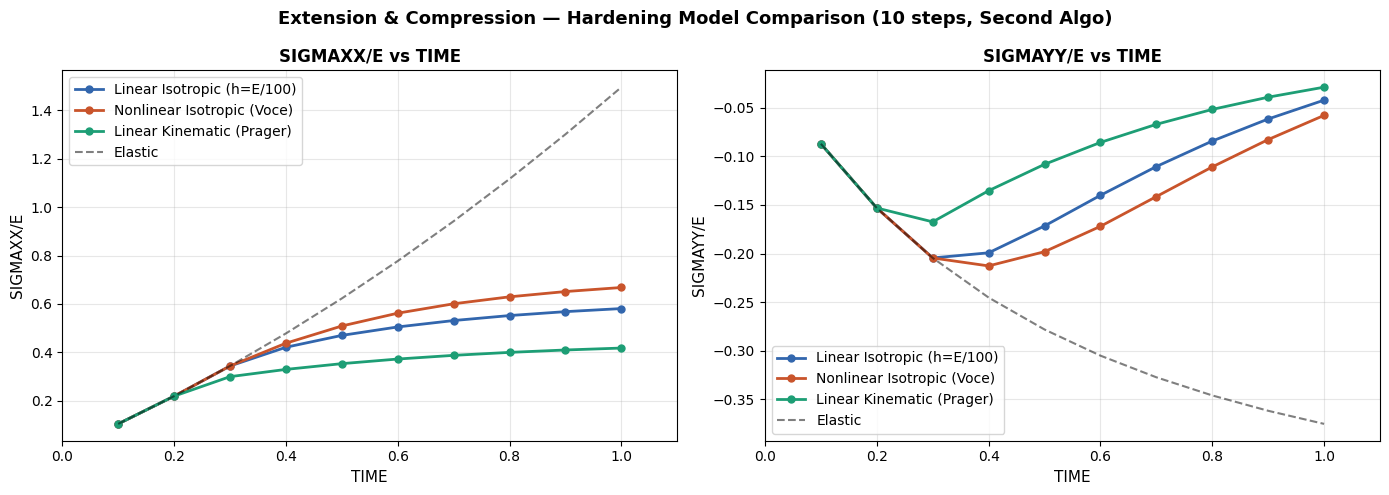

Saved: ext_comp_hardening_comparison.png


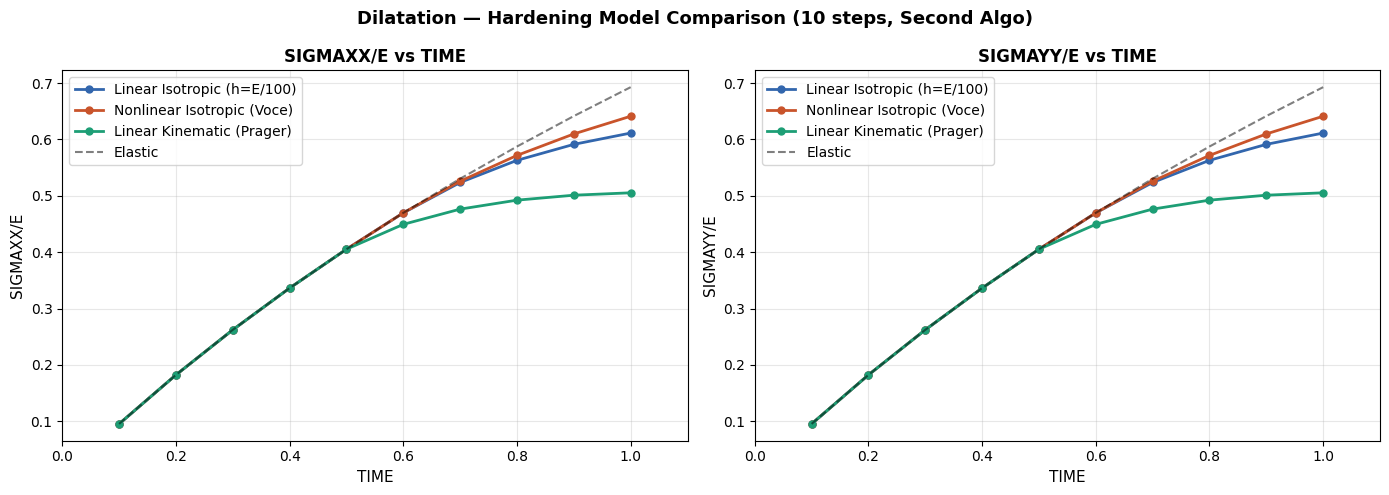

Saved: dilatation_hardening_comparison.png


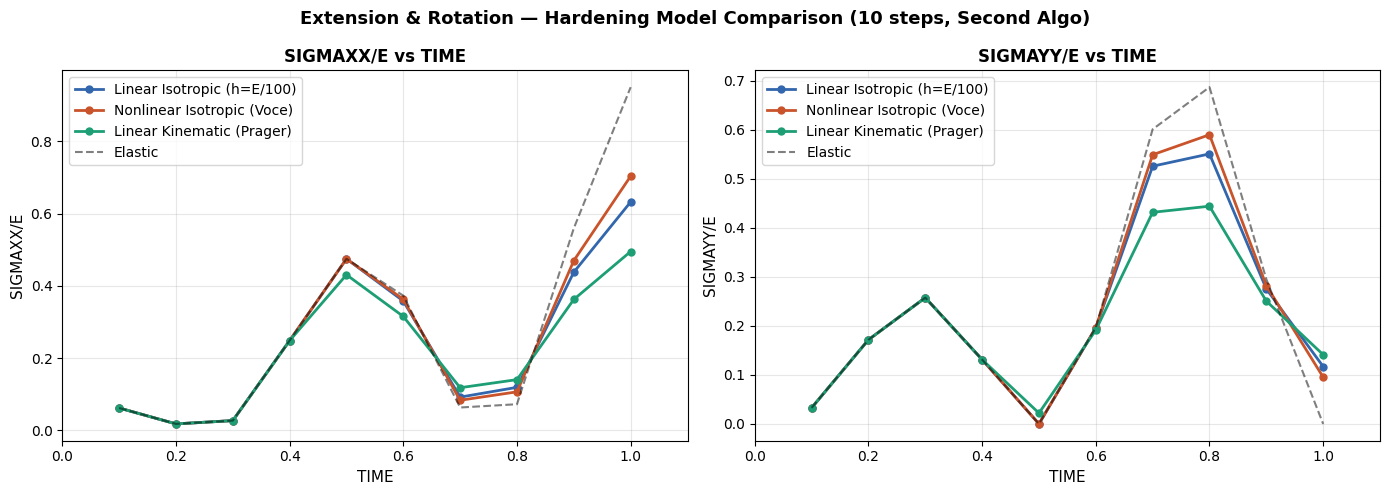

Saved: ext_rot_hardening_comparison.png


In [ ]:
STEP_COUNTS = [1, 5, 10, 50]
ALGOS       = ['small', 'first', 'second']
ALGO_LABELS = {'small':'Small strain (□)',
                'first':'First algo (▽)',
                'second':'Second algo (△)'}
ALGO_STYLES = {'small': dict(color='#3266ad', marker='s', ls='-'),
                'first': dict(color='#c9542b', marker='v', ls='--'),
                'second':dict(color='#1d9e75', marker='^', ls='-.')}

TESTS = [('ext_comp','Extension & Compression'),
            ('dilatation','Dilatation'),
            ('ext_rot','Extension & Rotation')]

HARDENING_MODELS = {
    'linear_iso':    dict(h=h),
    'nonlinear_iso': dict(Y_inf=Y_inf, delta=delta),
    'kinematic':     dict(H_kin=H_kin),
}
HARDENING_LABELS = {
    'linear_iso':    'Linear Isotropic (h=E/100)',
    'nonlinear_iso': 'Nonlinear Isotropic (Voce)',
    'kinematic':     'Linear Kinematic (Prager)',
}

# ── Paper validation: elastic + linear isotropic ─────────
for test_key, test_name in TESTS:
    for plastic in [False, True]:
        hardening = 'linear_iso' if plastic else 'elastic'
        label     = 'Plastic (Linear Iso)' if plastic else 'Elastic'

        fig, axes = plt.subplots(1, 2, figsize=(14,5))
        fig.suptitle(f'{test_name} — {label}',
                        fontsize=14, fontweight='bold')

        t_ref = np.linspace(0, 1, 300)
        if not plastic:
            sxx_a, syy_a = analytical_solution(test_key, t_ref)
            axes[0].plot(t_ref, sxx_a, 'k-', lw=2, alpha=0.5,
                            label='Analytical')
            axes[1].plot(t_ref, syy_a, 'k-', lw=2, alpha=0.5,
                            label='Analytical')

        for ns in STEP_COUNTS:
            ms = max(4, 9 - STEP_COUNTS.index(ns)*2)
            for algo in ALGOS:
                t, sxx, syy = run_algorithm(
                    test_key, ns, algo, hardening,
                    E, nu, Y0, h,
                    Y_inf=Y_inf, delta=delta,
                    H_kin=H_kin)
                sty = ALGO_STYLES[algo]
                lbl = f'{ALGO_LABELS[algo]} {ns}step'
                axes[0].plot(t, sxx, marker=sty['marker'], ms=ms,
                                ls=sty['ls'], color=sty['color'],
                                alpha=0.7, label=lbl)
                axes[1].plot(t, syy, marker=sty['marker'], ms=ms,
                                ls=sty['ls'], color=sty['color'],
                                alpha=0.7, label=lbl)

        for ax, comp in zip(axes, ['SIGMAXX/E','SIGMAYY/E']):
            ax.set_xlabel('TIME', fontsize=11)
            ax.set_ylabel(comp,   fontsize=11)
            ax.set_title(comp+' vs TIME', fontweight='bold')
            ax.set_xlim([0, 1.1])
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7, ncol=2)

        plt.tight_layout()
        fname = f'{test_key}_{label.lower().replace(" ","_")}.png'
        plt.savefig(fname, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

# ── Hardening comparison─────────────────────────────────────────
for test_key, test_name in TESTS:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f'{test_name} — Hardening Model Comparison (10 steps, Second Algo)',
                    fontsize=13, fontweight='bold')

    colors = {'linear_iso':'#3266ad',
                'nonlinear_iso':'#c9542b',
                'kinematic':'#1d9e75'}

    for hmodel, hparams in HARDENING_MODELS.items():
        t, sxx, syy = run_algorithm(
            test_key, 10, 'second', hmodel,
            E, nu, Y0, h,
            Y_inf=Y_inf, delta=delta,
            H_kin=H_kin)
        lbl = HARDENING_LABELS[hmodel]
        axes[0].plot(t, sxx, 'o-', color=colors[hmodel],
                        lw=2, ms=5, label=lbl)
        axes[1].plot(t, syy, 'o-', color=colors[hmodel],
                        lw=2, ms=5, label=lbl)

    t_e, sxx_e, syy_e = run_algorithm(
        test_key, 10, 'second', 'elastic',
        E, nu, Y0, h)
    axes[0].plot(t_e, sxx_e, 'k--', lw=1.5, alpha=0.5, label='Elastic')
    axes[1].plot(t_e, syy_e, 'k--', lw=1.5, alpha=0.5, label='Elastic')

    for ax, comp in zip(axes, ['SIGMAXX/E','SIGMAYY/E']):
        ax.set_xlabel('TIME', fontsize=11)
        ax.set_ylabel(comp, fontsize=11)
        ax.set_title(comp+' vs TIME', fontweight='bold')
        ax.set_xlim([0, 1.1])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

    plt.tight_layout()
    fname = f'{test_key}_hardening_comparison.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')